In [2]:
import os
import umap
import numpy   as np
import pandas  as pd
import seaborn as sns
import networkx as nx

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors     import kneighbors_graph
from sklearn.decomposition import PCA
from sklearn.cluster       import KMeans
from sklearn.preprocessing import normalize

In [6]:
from scipy.sparse.csgraph import connected_components, laplacian
from scipy.sparse.linalg  import eigsh

In [7]:
df = pd.read_csv("../data/processed/SDSS_DR16Q_phot_cleaned.csv")
print(df.describe())

                 Z          M_u          M_g          M_r          M_i  \
count  9536.000000  9536.000000  9536.000000  9536.000000  9536.000000   
mean      1.023579   -23.530820   -23.809128   -24.209070   -24.370806   
std       0.651872     1.242588     1.176459     1.160399     1.164881   
min       0.004153   -27.231554   -27.238091   -27.768663   -27.962621   
25%       0.487549   -24.449257   -24.698299   -25.089884   -25.268040   
50%       0.860302   -23.704003   -23.984312   -24.381034   -24.538051   
75%       1.449763   -22.698388   -22.983328   -23.354777   -23.487717   
max       2.998000   -13.022707   -13.312716   -13.485963   -13.780519   

               M_z        M_FUV        M_NUV         M_2j         M_2h  \
count  9536.000000  9536.000000  9536.000000  9536.000000  9536.000000   
mean    -24.598316   -21.398616   -22.627769   -24.909736   -25.220661   
std       1.191735     2.001444     1.729957     1.243953     1.210844   
min     -28.140199   -26.006954   -26

In [8]:
df_features = pd.DataFrame(index=df.index)

# Colores optivos y UV (Emision del disco)
df_features['u_g'] = df['M_u'] - df['M_g']
df_features['g_r'] = df['M_g'] - df['M_r']
df_features['r_i'] = df['M_r'] - df['M_i']
df_features['i_z'] = df['M_i'] - df['M_z']
df_features['FUV_NUV'] = df['M_FUV'] - df['M_NUV']

# Colores Infrarrojos (Emisión térmica del polvo/toroide)
df_features['j_h'] = df['M_2j'] - df['M_2h']
df_features['h_k'] = df['M_2h'] - df['M_2k']
df_features['W1_W2'] = df['M_W1'] - df['M_W2']

# Cruces espectrales (Relación óptica-infrarroja)
df_features['i_W1'] = df['M_i'] - df['M_W1']
df_features['r_W2'] = df['M_r'] - df['M_W2']

# Big Blue Bump
df_features["NUV_u"] = df["M_NUV"] - df["M_u"]
df_features["NUV_g"] = df["M_NUV"] - df["M_g"]

In [9]:
print(df_features.describe())

               u_g          g_r          r_i          i_z      FUV_NUV  \
count  9536.000000  9536.000000  9536.000000  9536.000000  9536.000000   
mean      0.278307     0.399943     0.161735     0.227510     1.229153   
std       0.258463     0.193748     0.124301     0.142974     1.629387   
min      -4.870668    -5.615912    -3.743732    -1.621707    -5.853674   
25%       0.142703     0.294971     0.093514     0.164844     0.171000   
50%       0.222623     0.365328     0.150239     0.230015     0.782527   
75%       0.341722     0.459359     0.213270     0.290046     1.733545   
max       7.056376     5.479307     1.342831     7.410069    12.451260   

               j_h          h_k        W1_W2         i_W1         r_W2  \
count  9536.000000  9536.000000  9536.000000  9536.000000  9536.000000   
mean      0.310925     0.336048     0.783029     1.573230     2.517994   
std       0.319400     0.343519     0.175277     0.440206     0.491446   
min      -1.502303    -1.632679    -1

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [11]:
pca = PCA()
pca.fit(X_scaled)

exp_variance = pca.explained_variance_ratio_
acc_variance = np.cumsum(exp_variance)

In [12]:
n_components = np.argmax(acc_variance >= 0.95) + 1

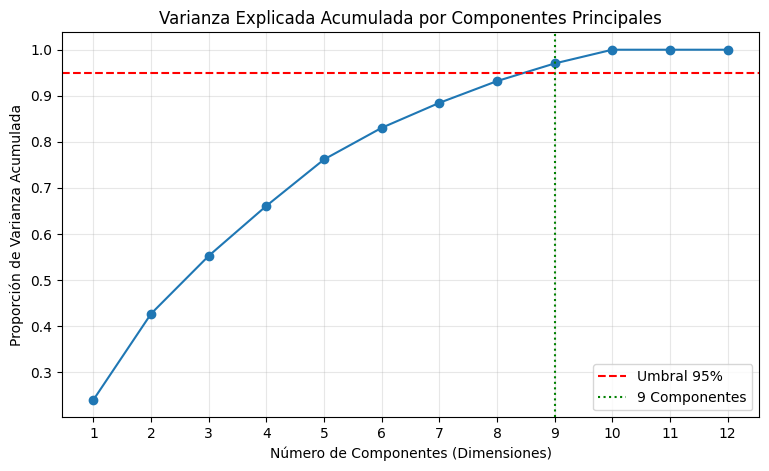

In [13]:
plt.figure(figsize=(9, 5))
# Gráfico de la varianza acumulada
plt.plot(range(1, len(acc_variance) + 1), acc_variance, marker='o', linestyle='-')

# Líneas de referencia para el 95%
plt.axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
plt.axvline(x=n_components, color='g', linestyle=':', label=f'{n_components} Componentes')

plt.title('Varianza Explicada Acumulada por Componentes Principales')
plt.xlabel('Número de Componentes (Dimensiones)')
plt.ylabel('Proporción de Varianza Acumulada')
plt.xticks(range(1, len(acc_variance) + 1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
reducer = umap.UMAP(
    n_components=n_components, 
    metric='manhattan',
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

c:\Users\jm_ra\OneDrive\Documentos\investigacion\Network-Analysis-of-Quasars\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
n_samples = X_umap.shape[0]
k_values  = range(2, 21)
gcc_percentages = []

for k in k_values:
    # 1. Create standard directed k-NN connectivity graph
    A_knn = kneighbors_graph(
        X_umap, 
        n_neighbors=k, 
        mode='distance', 
        metric='manhattan',
        include_self=False
    )
    
    # 2. Convert to Mutual k-NN graph
    A_mutual = A_knn.multiply(A_knn.T)
    
    # 3. Find connected components in the mutual graph
    n_components, labels = connected_components(
        csgraph=A_mutual, 
        directed=False, 
        return_labels=True
    )
    
    # 4. Calculate the size of the Giant Connected Component (GCC)
    unique_labels, counts = np.unique(labels, return_counts=True)
    gcc_size = np.max(counts)
    gcc_percentage = (gcc_size / n_samples) * 100
    
    gcc_percentages.append(gcc_percentage)

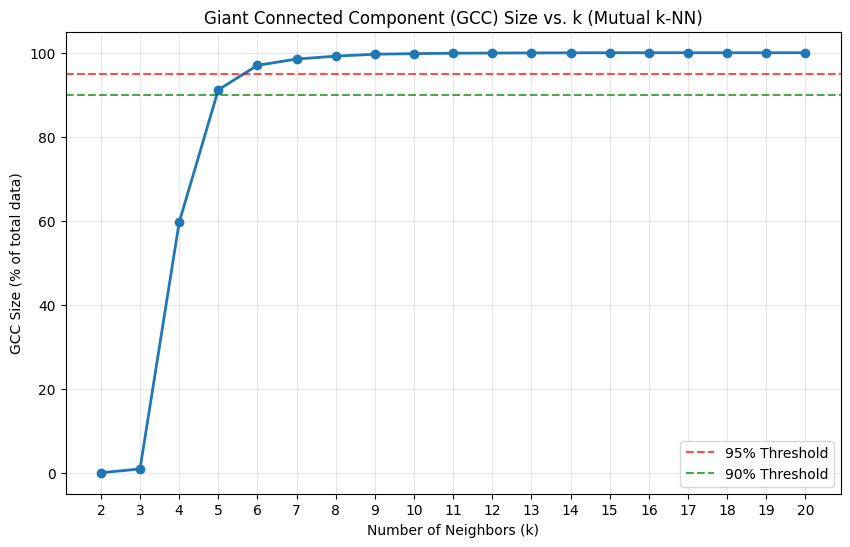

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, gcc_percentages, marker='o', linestyle='-', linewidth=2)
plt.axhline(y=95, color='r', linestyle='--', alpha=0.7, label='95% Threshold')
plt.axhline(y=90, color='g', linestyle='--', alpha=0.7, label='90% Threshold')

plt.title('Giant Connected Component (GCC) Size vs. k (Mutual k-NN)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('GCC Size (% of total data)')
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [17]:
# 1. Obtenemos el grafo de distancias (k-NN)
A_dist = kneighbors_graph(
    X_umap, 
    n_neighbors=7, 
    mode='distance', 
    metric='manhattan',
    include_self=False
)

A_dist.shape

(9536, 9536)

In [18]:
mutual_mask   = (A_dist > 0).multiply((A_dist.T > 0))
A_dist_mutual = A_dist.multiply(mutual_mask)

sigma = np.mean(A_dist_mutual.data)

A_dist_mutual.data = np.exp(- (A_dist_mutual.data**2) / (sigma**2))

# Limpiar valores microscópicos (ej. menores a 1e-4)
A_dist_mutual.data[A_dist_mutual.data < 1e-4] = 0
A_dist_mutual.eliminate_zeros() # Esto re-estructura la matriz dispersa

In [19]:
# 1. Find connected components in the mutual distance graph
n_components, labels = connected_components(
    csgraph=A_dist_mutual, 
    directed=False, 
    return_labels=True
)

# 2. Identify the label of the largest component
unique_labels, counts = np.unique(labels, return_counts=True)
gcc_label = unique_labels[np.argmax(counts)]

# 3. Create a boolean mask for the GCC
gcc_mask = (labels == gcc_label)

# 4. Filter the adjacency matrix to keep only GCC nodes
# We use indexing to slice both rows and columns
A_gcc = A_dist_mutual[gcc_mask][:, gcc_mask]

print(f"Original nodes: {A_dist_mutual.shape[0]} | GCC nodes: {A_gcc.shape[0]}")

Original nodes: 9536 | GCC nodes: 9383


In [20]:
# 1. Compute the symmetric normalized Laplacian
L_norm = laplacian(A_gcc, normed=True)

# 2. Calculate the first 25 smallest eigenvalues and eigenvectors
n_evals = 25
eigenvalues, eigenvectors = eigsh(L_norm, k=n_evals, which='SM')

# 3. Sort them in ascending order (eigsh doesn't always guarantee strict order)
sort_indices = np.argsort(eigenvalues)
eigenvalues = eigenvalues[sort_indices]
eigenvectors = eigenvectors[:, sort_indices]

# 4. Calculate the Eigengap (difference between consecutive eigenvalues)
eigengaps = np.diff(eigenvalues)

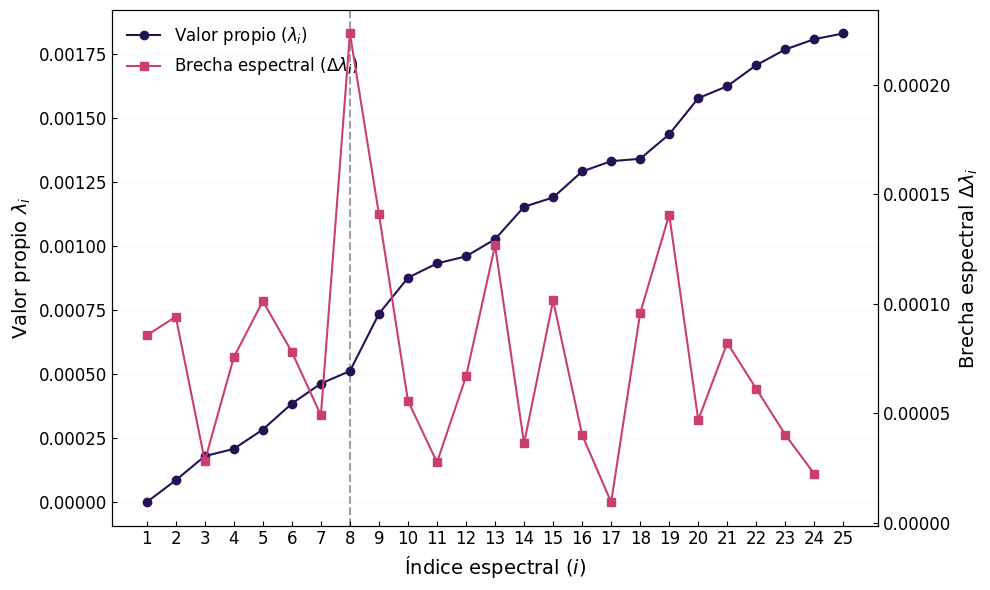

In [21]:
# Estilo minimalista por defecto
plt.style.use('default')

# Tu K óptimo (donde ocurre el salto)
k_opt = 8

fig, ax1 = plt.subplots(figsize=(10, 6))

# Extraer colores contrastantes directamente de la paleta Magma
color_eigen = cm.magma(0.15)
color_gap = cm.magma(0.55)

# --- EJE IZQUIERDO: Valores Propios ---
line1 = ax1.plot(range(1, n_evals + 1), eigenvalues, marker='o', linestyle='-', 
                 color=color_eigen, linewidth=1.5, markersize=6, 
                 label=r'Valor propio ($\lambda_i$)')

ax1.set_xlabel(r'Índice espectral ($i$)', fontsize=14)
ax1.set_ylabel(r'Valor propio $\lambda_i$', fontsize=14)
ax1.tick_params(axis='y', direction='in', labelsize=12)
ax1.tick_params(axis='x', direction='in', labelsize=12)
ax1.set_xticks(range(1, n_evals + 1))

# --- EJE DERECHO: Brecha Espectral ---
ax2 = ax1.twinx()
line2 = ax2.plot(range(1, n_evals), eigengaps, marker='s', linestyle='-', 
                 color=color_gap, linewidth=1.5, markersize=6, 
                 label=r'Brecha espectral ($\Delta \lambda_i$)')

ax2.set_ylabel(r'Brecha espectral $\Delta \lambda_i$', fontsize=14)
ax2.tick_params(axis='y', direction='in', labelsize=12)

# --- INDICADOR MINIMALISTA DE K ÓPTIMO ---
# Una simple línea punteada gris muy tenue de fondo
ax1.axvline(x=k_opt, color='gray', linestyle='--', linewidth=1.5, alpha=0.75, zorder=0)

# --- LEYENDA UNIFICADA ---
lines = line1 + line2
labels = [l.get_label() for l in lines]
# Leyenda sin recuadro para no saturar
ax1.legend(lines, labels, loc='upper left', fontsize=12, frameon=False)

# Grid extremadamente sutil solo en el eje Y principal
ax1.grid(axis='y', alpha=0.1)

plt.tight_layout()
plt.savefig('../results/figures/eigengap_minimalist_magma.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [22]:
# Based on the eigengap heuristic, set the optimal number of clusters
optimal_r = 8

print(f"Applying KMeans on the first {optimal_r} eigenvectors...")

# 1. Extract the first 'r' eigenvectors
U = eigenvectors[:, 0:optimal_r]

# 2. Normalize the rows of the eigenvector matrix to unit length (L2 norm)
U_normalized = normalize(U, axis=1, norm='l2')

# 3. Apply KMeans clustering
kmeans = KMeans(n_clusters=optimal_r, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(U_normalized)

print("Spectral Clustering complete!")

Applying KMeans on the first 8 eigenvectors...
Spectral Clustering complete!


In [23]:
# --- 2. VISUALIZACIÓN DEL GRAFO ---
X_umap_gcc = X_umap[gcc_mask]

# Extraer las conexiones (aristas) de la matriz de adyacencia del GCC
coo = A_gcc.tocoo()
# Filtramos para dibujar solo una vez cada arista (grafo no dirigido)
mask = coo.row < coo.col 
edges_row = coo.row[mask]
edges_col = coo.col[mask]

# Obtener las coordenadas de inicio y fin para cada línea
edge_coords = np.empty((len(edges_row), 2, 2))

# El ", :2" extrae solo las dimensiones 0 y 1 (x e y) para el gráfico de matplotlib
edge_coords[:, 0, :] = X_umap_gcc[edges_row, :2]
edge_coords[:, 1, :] = X_umap_gcc[edges_col, :2]

In [24]:
G = nx.from_scipy_sparse_array(A_gcc)

k_candidates = [6, 8, 16]

best_k = None
best_modularity = -1
best_labels = None

print(f"{'k (Clústeres)':>15} | {'Modularidad (Q)':>15} | {'Inercia K-Means':>15}")
print("-" * 52)

for k in k_candidates:
    # A. Tomar las primeras 'k' columnas de autovectores
    # (Que corresponden a los 'k' autovalores más pequeños que ya ordenaste)
    U = eigenvectors[:, :k]
    
    # B. NORMALIZAR las filas (Paso clave del algoritmo de Ng, Jordan y Weiss)
    # Esto proyecta los puntos en una esfera unitaria, haciendo que los 
    # clústeres sean mucho más fáciles de separar para K-Means por su ángulo.
    U_normalized = normalize(U, axis=1, norm='l2')
    
    # C. Aplicar K-Means sobre ese espacio latente
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(U_normalized)
    
    # D. Preparar las comunidades para calcular la Modularidad
    # NetworkX requiere una lista donde cada elemento es un "set" con los índices de los nodos
    communities = [set(np.where(labels == c)[0]) for c in range(k)]
    
    # E. Calcular la Modularidad (Q) usando los pesos originales del grafo
    modularity = nx.algorithms.community.modularity(G, communities, weight='weight')
    
    print(f"{k:15} | {modularity:15.4f} | {kmeans.inertia_:15.4f}")
    
    # Guardar el mejor resultado
    if modularity > best_modularity:
        best_modularity = modularity
        best_k = k
        best_labels = labels

print("-" * 52)
print(f"🌟 El mejor número de clústeres según Modularidad es k={best_k} (Q={best_modularity:.4f})")

  k (Clústeres) | Modularidad (Q) | Inercia K-Means
----------------------------------------------------
              6 |          0.7885 |       1308.5505
              8 |          0.8542 |        988.1236
             16 |          0.9157 |       1334.9173
----------------------------------------------------
🌟 El mejor número de clústeres según Modularidad es k=16 (Q=0.9157)


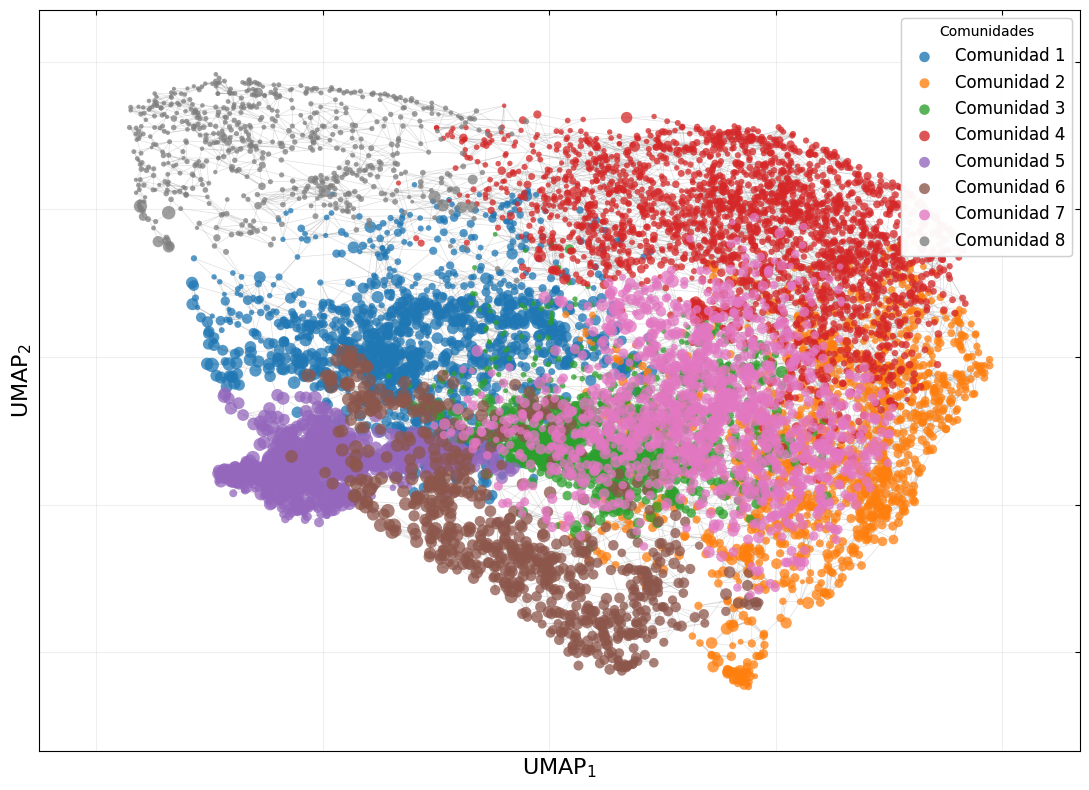

In [28]:
# 0. Estilo clásico
plt.style.use('default')

k_vis = 8

# Recalcular clústeres
U_vis = eigenvectors[:, :k_vis]
U_normalized_vis = normalize(U_vis, axis=1, norm='l2')
kmeans_vis = KMeans(n_clusters=k_vis, random_state=42, n_init=10)
labels_vis = kmeans_vis.fit_predict(U_normalized_vis)

fig, ax = plt.subplots(figsize=(11, 8))

# 1. Extraer Z del DataFrame original y aplicar las máscaras
Z_outliers = df['Z'][~gcc_mask].values
Z_gcc = df['Z'][gcc_mask].values

# 2. Definir una función de escala para el tamaño (s)
def escalar_tamaño(z_array):
    return 5 + (35 * z_array)

# -------------------------------------------------------------------------
# NUEVO PASO: DIBUJAR LAS ARISTAS DEL GRAFO (EDGES)
# -------------------------------------------------------------------------
X_umap_gcc = X_umap[gcc_mask]

# Creamos un diccionario de posiciones {nodo_id: (x, y)} para networkx
# Nota: Esto asume que los nodos en tu grafo G_gcc están indexados secuencialmente de 0 a N-1
posiciones_gcc = {i: (X_umap_gcc[i, 3], X_umap_gcc[i, 5]) for i in range(len(X_umap_gcc))}

# Dibujamos SOLO las aristas (edge_color gris tenue) y las mandamos al fondo con zorder=0
nx.draw_networkx_edges(
    G, 
    pos=posiciones_gcc, 
    ax=ax, 
    alpha=0.25,        # Transparencia altísima obligatoria para no tapar los datos
    edge_color='gray',
    width=0.5          # Líneas muy finas
)
# -------------------------------------------------------------------------

# 4. Graficar el GCC con una paleta categórica fuerte
colores_cluster = sns.color_palette("tab10", n_colors=k_vis)

for cluster_id in range(k_vis):
    cluster_mask = (labels_vis == cluster_id)
    
    ax.scatter(
        X_umap_gcc[cluster_mask, 3], 
        X_umap_gcc[cluster_mask, 5], 
        color=colores_cluster[cluster_id], 
        label=f'Comunidad {cluster_id + 1}', 
        alpha=0.75,  
        s=escalar_tamaño(Z_gcc[cluster_mask]),
        edgecolor='none',
        zorder=2  # zorder=2 asegura que los puntos tapen las líneas del grafo
    )

# 5. Detalles estéticos
ax.set_xlabel(r'$\text{UMAP}_1$', fontsize=16)
ax.set_ylabel(r'$\text{UMAP}_2$', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14, direction='in', top=True, right=True)

# 6. Crear una doble leyenda (Una para Clústeres, otra para Tamaños Z)
leg1 = ax.legend(loc='upper right', fontsize=12, frameon=True, title="Comunidades")
ax.add_artist(leg1) 

z_references = [1.0, 3.0, 5.0]
for z_val in z_references:
    ax.scatter([], [], s=escalar_tamaño(z_val), color='gray', alpha=0.6, label=f'$z = {z_val}$')


plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('../results/figures/skeleton_graph_weighted.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [52]:
# 1. Recuperar los índices de los datos originales que sobrevivieron al filtro GCC
# Usamos df_clean (el que no tenía NaNs) y aplicamos la máscara del GCC
indices_gcc = df.index[gcc_mask]

# 2. Crear un nuevo DataFrame solo con los cuásares del grafo final
df_gcc = df.loc[indices_gcc].copy()

# 3. Asignar las nuevas etiquetas de comunidad
df_gcc['community'] = cluster_labels

# 4. Asegurarnos de que el directorio de destino exista
output_dir = '../data/communities/by_color/'
os.makedirs(output_dir, exist_ok=True)

# 5. Iterar dinámicamente sobre las comunidades encontradas
comunidades_unicas = np.unique(cluster_labels)

print("Guardando archivos...")
for i in comunidades_unicas:
    # Filtramos la comunidad actual
    df_temp = df_gcc[df_gcc['community'] == i]
    
    # Generamos la ruta y guardamos
    filename = f'{output_dir}df_community_{i}.csv'
    df_temp.to_csv(filename, index=False)
    
    print(f" -> Comunidad {i}: {len(df_temp)} objetos guardados en {filename}")

print("¡Proceso completado!")

Guardando archivos...
 -> Comunidad 0: 1242 objetos guardados en ../data/communities/by_color/df_community_0.csv
 -> Comunidad 1: 1273 objetos guardados en ../data/communities/by_color/df_community_1.csv
 -> Comunidad 2: 1030 objetos guardados en ../data/communities/by_color/df_community_2.csv
 -> Comunidad 3: 2329 objetos guardados en ../data/communities/by_color/df_community_3.csv
 -> Comunidad 4: 866 objetos guardados en ../data/communities/by_color/df_community_4.csv
 -> Comunidad 5: 716 objetos guardados en ../data/communities/by_color/df_community_5.csv
 -> Comunidad 6: 1307 objetos guardados en ../data/communities/by_color/df_community_6.csv
 -> Comunidad 7: 620 objetos guardados en ../data/communities/by_color/df_community_7.csv
¡Proceso completado!


In [53]:
# 1. Binarizamos la matriz (1 = hay arista, 0 = no hay arista)
A_binaria = (A_gcc > 0).astype(int)

# 2. Convertimos la matriz dispersa de SciPy a un grafo de NetworkX
# (Si tu versión de networkx es antigua, cambia "from_scipy_sparse_array" por "from_scipy_sparse_matrix")
G = nx.from_scipy_sparse_array(A_binaria)

# 3. Calculamos el coeficiente de agrupamiento local para cada nodo
# Devuelve un diccionario {nodo_id: coeficiente}
local_clustering = nx.clustering(G)

# 4. Calculamos el promedio global del grafo
global_clustering = nx.average_clustering(G)
print(f"Coeficiente de agrupamiento global: {global_clustering:.4f}")

# 5. Pasamos los coeficientes a tu DataFrame df_gcc
# Al crearse desde la matriz, los nodos del grafo van de 0 a N-1 secuencialmente
df_gcc = df_gcc.copy()
df_gcc['local_clustering'] = [local_clustering[i] for i in range(A_gcc.shape[0])]

# 6. Filtramos y buscamos los Top 10 arquetipos por comunidad
top_10_representantes = (
    df_gcc[df_gcc['local_clustering'] > global_clustering]
    .sort_values(by=['community', 'local_clustering'], ascending=[True, False])
    .groupby('community')
    .head(10)
)

top_10_representantes.to_csv("../data/processed/top_10_per_community.csv")

Coeficiente de agrupamiento global: 0.4548
